# 2.5 Optimal Trading Strategy

In this notebook, we convert the synthetic alpha signals from Section 2.4 into actual trade schedules.

The previous sections provide:

$$
\text{prices},\quad
\text{fitted impact parameters},\quad
\text{backtest engine},\quad
\text{synthetic alpha}.
$$

The goal here is to produce trade panels

$$
q_{i,d,j},
$$

where $i$ is the stock, $d$ is the date, and $j$ is the intraday time bin. Positive trades are buys and negative trades are sells.

 - ####  **OW Strategy**
The strategy is based on the OW target-impact rule from the lecture notes. Under OW,

$$
I_{i,d,j}
=
e^{-\beta_i\Delta t}I_{i,d,j-1}
+
\lambda_i\sigma_i\frac{q_{i,d,j}}{ADV_i}.
$$

For OW, the fitted impact is essentially:

$$
I_t
=
\hat{\lambda}
\left(
a I_{t-\Delta t}
+
\frac{\sigma}{ADV}q_t
\right).
$$

For a deterministic alpha process, the target impact is

$$
I^*_{i,d,j}
=
\frac{1}{2}
\left(
\alpha_{i,d,j}
-
\frac{1}{\beta_i}\alpha'_{i,d,j}
\right).
$$

In discrete time,

$$
\alpha'_{i,d,j}
\approx
\frac{\alpha_{i,d,j}-\alpha_{i,d,j-1}}{\Delta t}.
$$

Then trades are recovered from the fitted OW impact equation:

$$
q_{i,d,j}
=
\frac{ADV_i}{\lambda_i\sigma_i}
\left(
I^*_{i,d,j}
-
e^{-\beta_i\Delta t}I^*_{i,d,j-1}
\right).
$$

So the core flow is:

$$
\alpha
\longrightarrow
\alpha'
\longrightarrow
I^*
\longrightarrow
q.
$$


- ### **AFS Strategy**

Let

$$
a = e^{-\beta \Delta t}.
$$

Then the AFS state is:

$$
J_{i,d,j}
=
aJ_{i,d,j-1}
+
\frac{\sigma_i}{ADV_i}q_{i,d,j}.
$$

Then the normalized AFS impact feature is:

$$
\bar{I}^{AFS}_{i,d,j}
=
\operatorname{sign}(J_{i,d,j})
\sqrt{|J_{i,d,j}|}.
$$

Then fitted return impact is:

$$
I^{AFS}_{i,d,j}
=
\hat{\lambda}_i
\operatorname{sign}(J_{i,d,j})
\sqrt{|J_{i,d,j}|}.
$$
For AFS, the notes state:

$$
I_t = \operatorname{sign}(J_t)|J_t|^c,
\qquad
dJ_t = -\beta J_t dt + \lambda dQ_t
$$

and the optimal target impact is:

$$
I_t^* = \frac{1}{1+c}
\left(
\alpha_t - \beta^{-1}\alpha_t'
\right).
$$

So for square-root AFS, $c = \frac{1}{2}$, hence:

$$
I_t^*
=
\frac{2}{3}
\left(
\alpha_t - \beta^{-1}\alpha_t'
\right).
$$

To get trades, we must go backwards:

$$
I_t^* \rightarrow J_t^* \rightarrow q_t.
$$

Since the fitted AFS impact is:

$$
I_t^*
=
\hat{\lambda}_i
\operatorname{sign}(J_t^*)
|J_t^*|^c,
$$

first divide by $\hat{\lambda}_i$:

$$
\bar{I}_t^*
=
\frac{I_t^*}{\hat{\lambda}_i}.
$$

Then invert:

$$
J_t^*
=
\operatorname{sign}(\bar{I}_t^*)
|\bar{I}_t^*|^{1/c}.
$$


Recover trades from the target $J$ state:

$$
J_t^*
=
aJ_{t-\Delta t}^*
+
\frac{\sigma}{ADV}q_t.
$$

Therefore:

$$
q_t
=
\frac{ADV}{\sigma}
\left(
J_t^*
-
aJ_{t-\Delta t}^*
\right).
$$
We first build the baseline intraday-alpha strategy, then add a TWAP benchmark, and finally add the overnight-alpha extension.

## 1. Imports and paths

This notebook assumes that the helper `.py` files and the saved results from Sections 2.1--2.4 are available in the same folder as this notebook.

In [51]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import src.data_prep as data_prep
import src.backtest_engine as backtest_engine
import src.optimal_trading_strategies as optimal_trading_strategies

DATA_DIR = r"data"

sys.path.append(str(DATA_DIR))

from src.data_prep import *
from src.backtest_engine import *
from src.optimal_trading_strategies import *

## 2. Load outputs from previous sections

This section imports the objects created in Sections 2.1--2.4.

From Section 2.1:

- `test_px_df`: observed test-period mid-prices $P_{i,d,j}$;
- `test_traded_volume_df`: public market traded volume $\Delta Q^{mkt}_{i,d,j}$;
- `scaling_df`: stock-level $ADV_i$ and $\sigma_i$.

From Section 2.2:

- `stock_results_df`: fitted stock-level impact results across model types and half-lives;
- `best_df`: selected best half-life for each model type.

From Section 2.4:

- `synthetic_alpha_df`: synthetic intraday alpha $\alpha^{intra}_{i,d,j}$;
- `synthetic_alpha_diagnostics_df`: alpha-construction diagnostics.

All stock-date-time panels must have the same index and intraday columns.

In [41]:
# Section 2.1 outputs: price and traded-volume panels.
train_px_df = load_panel_csv(os.path.join(DATA_DIR, "train_px_201901_20.csv"))
test_px_df = load_panel_csv(os.path.join(DATA_DIR, "test_px_201902_20.csv"))
test_traded_volume_df = load_panel_csv(os.path.join(DATA_DIR, "test_traded_volume_201902_20.csv"))

# Section 2.1 output: stock-level scaling variables.
scaling_df = load_stock_level_csv(os.path.join(DATA_DIR, "scaling_201901_20.csv"))

# Section 2.2 outputs: fitted impact model parameters.
best_df = pd.read_csv(
    os.path.join(DATA_DIR, "impact_model_best_by_is_201901_train_201902_test.csv")
)

stock_results_df = pd.read_csv(
    os.path.join(DATA_DIR, "impact_model_stock_results_201901_train_201902_test.csv")
)

# Section 2.4 outputs: synthetic alpha panel and diagnostics.
synthetic_alpha_df = load_panel_csv(
    os.path.join(DATA_DIR, "synthetic_alpha_201902_20.csv")
)

synthetic_alpha_diagnostics_df = load_stock_level_csv(
    os.path.join(DATA_DIR, "synthetic_alpha_diagnostics_201902_20.csv")
)

# Keep only common intraday columns across all panel objects.
# This is needed because the strategy computes trades time-bin by time-bin.
test_px_df, test_traded_volume_df, synthetic_alpha_df = align_intraday_columns(
    test_px_df,
    test_traded_volume_df,
    synthetic_alpha_df,
)

# Basic shape checks.
print("train_px_df:", train_px_df.shape)
print("test_px_df:", test_px_df.shape)
print("test_traded_volume_df:", test_traded_volume_df.shape)
print("synthetic_alpha_df:", synthetic_alpha_df.shape)
print("synthetic_alpha_diagnostics_df:", synthetic_alpha_diagnostics_df.shape)
print("scaling_df:", scaling_df.shape)
print("best_df:", best_df.shape)
print("stock_results_df:", stock_results_df.shape)

# These three panels must now have the same shape.
assert test_px_df.shape == test_traded_volume_df.shape
assert test_px_df.shape == synthetic_alpha_df.shape
assert test_px_df.columns.equals(test_traded_volume_df.columns)
assert test_px_df.columns.equals(synthetic_alpha_df.columns)

train_px_df: (420, 2341)
test_px_df: (380, 2341)
test_traded_volume_df: (380, 2341)
synthetic_alpha_df: (380, 2341)
synthetic_alpha_diagnostics_df: (20, 8)
scaling_df: (20, 2)
best_df: (3, 9)
stock_results_df: (420, 25)


## 3. Reconstruct fitted model parameter tables

Section 2.2 fitted each model over a grid of half-lives. Here we select, for each model type, the stock-level rows corresponding to the best half-life chosen in Section 2.2.

For Section 2.5, the important parameters are

$$
\lambda_i
\quad \text{and} \quad
H_i.
$$

The OW fitted table is used to generate the OW target-impact trade schedules. The AFS and reduced-form fitted tables are only used later for optional robustness backtests.

In [42]:
model_types = ["ow", "afs", "reduced_form"]

required_cols = ["lambda_hat", "half_life_seconds", "is_r2", "oos_r2"]

fit_dfs = {}
fit_summary_rows = []

test_stocks = set(test_px_df.index.get_level_values(0).unique())

for model_type in model_types:
    fit_df = get_best_model_fit_df(
        stock_results_df=stock_results_df,
        best_df=best_df,
        model_type=model_type,
    )

    missing_cols = [col for col in required_cols if col not in fit_df.columns]
    if len(missing_cols) > 0:
        raise ValueError(f"{model_type} fit_df is missing columns: {missing_cols}")

    fit_dfs[model_type] = fit_df

    selected_half_life_seconds = fit_df["half_life_seconds"].iloc[0]
    selected_half_life_minutes = selected_half_life_seconds / 60

    missing_stocks = sorted(test_stocks - set(fit_df.index))

    fit_summary_rows.append({
        "model_type": model_type,
        "n_stocks": fit_df.shape[0],
        "selected_half_life_minutes": selected_half_life_minutes,
        "mean_is_r2": fit_df["is_r2"].mean(),
        "mean_oos_r2": fit_df["oos_r2"].mean(),
        "n_missing_test_stocks": len(missing_stocks),
    })

fit_summary_df = pd.DataFrame(fit_summary_rows)

display(fit_summary_df)

for model_type, fit_df in fit_dfs.items():
    print(model_type)
    display(fit_df[required_cols].head())

,model_type,n_stocks,selected_half_life_minutes,mean_is_r2,mean_oos_r2,n_missing_test_stocks
0,ow,20,30.0,0.167120,0.158372,0
1,afs,20,5.0,0.153022,0.149694,0
2,reduced_form,20,10.0,0.196336,0.179360,0


ow


,lambda_hat,half_life_seconds,is_r2,oos_r2
stock,,,,
AAL,262.866026,1800,0.143934,0.199819
AAPL,407.392206,1800,0.231705,0.252164
ABBV,382.822089,1800,0.130716,0.131900
ABT,440.867448,1800,0.171972,0.115936
ADBE,339.189338,1800,0.123732,0.137870


afs


,lambda_hat,half_life_seconds,is_r2,oos_r2
stock,,,,
AAL,0.770608,300,0.151269,0.185629
AAPL,0.828313,300,0.234038,0.227081
ABBV,0.540337,300,0.102414,0.115905
ABT,0.550386,300,0.133748,0.099200
ADBE,0.573366,300,0.130973,0.123505


reduced_form


,lambda_hat,half_life_seconds,is_r2,oos_r2
stock,,,,
AAL,73.752339,600,0.181003,0.244088
AAPL,106.653594,600,0.281354,0.309429
ABBV,89.711831,600,0.151770,0.123431
ABT,99.691282,600,0.186580,0.098858
ADBE,87.620862,600,0.156239,0.175975


## 4. Strategy containers and global settings

We keep the strategy outputs in dictionaries. This makes it clear which trade panel belongs to which strategy.

The participation target is applied to total absolute daily volume:

$$
\sum_j |q_{i,d,j}| = 0.20 \times ADV_i.
$$

This normalization makes strategy comparisons easier, but it means the trade schedules are best described as OW target-impact shapes normalized to fixed participation, not the unconstrained analytical optimum.

In [43]:
dt_seconds = 10
target_participation = 0.20

ow_fit_df = fit_dfs["ow"]

alpha_scenarios = {} # stores alpha signals
strategy_trade_dfs = {} # stores actual trades q_t used in backtest
target_impact_dfs = {} # stores I*_t from OW formula
alpha_prime_dfs = {} # stores alpha derivatives
strategy_scale_dfs = {} # stores normalization diagnostics

# Strategy_trades_df:
# raw_abs_volume      = volume before scaling
# target_abs_volume   = 0.20 * ADV
# actual_abs_volume   = volume after scaling
# scale_factor        = target_abs_volume / raw_abs_volume
# net_traded          = total buys - sells


## 5. Baseline alpha scenario: intraday alpha only

We first run the strategy using only the synthetic intraday alpha from Section 2.4.

At this stage, we do not include overnight alpha. The purpose is to check the core pipeline:

$$
\alpha^{intra}_{i,d,j}
\longrightarrow
q_{i,d,j}.
$$

In [44]:
alpha_scenarios["intraday_only"] = synthetic_alpha_df.copy()

trades_df, target_impact_df, alpha_prime_df, strategy_scale_df = make_ow_optimal_trade_df(
    alpha_df=alpha_scenarios["intraday_only"],
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    fit_df=ow_fit_df,
    dt_seconds=dt_seconds,
    normalize_abs_volume=True,
    target_participation=target_participation,
)

strategy_trade_dfs["intraday_only"] = trades_df
target_impact_dfs["intraday_only"] = target_impact_df
alpha_prime_dfs["intraday_only"] = alpha_prime_df
strategy_scale_dfs["intraday_only"] = strategy_scale_df

print("intraday_only")
print("  total abs traded:", trades_df.abs().sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())
print("  net traded:", trades_df.sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())
print("  scale factor:", strategy_scale_df["scale_factor"].describe()[["mean", "50%", "min", "max"]].to_dict())

display(strategy_scale_df.head())

intraday_only
  total abs traded: {'mean': 210496.52095238105, '50%': 86099.19523809524, 'min': 51435.323809523805, 'max': 1848185.8476190486}
  net traded: {'mean': 7.471213280040334, '50%': 2.866260921207024, 'min': -1481.3785007583124, 'max': 1889.875209489699}
  scale factor: {'mean': 0.0020741325158605546, '50%': 0.0020261484209469502, 'min': 0.0010940803680620393, 'max': 0.0034378876210678613}


,stock,date,ADV,sigma,lambda_hat,half_life_seconds,beta,target_participation,target_abs_volume,raw_abs_volume,actual_abs_volume,net_traded,scale_factor,normalize_abs_volume
0,AAL,2019-02-01,1.236722e+06,0.000528,262.866026,1800.0,0.000385,0.2,247344.466667,1.555665e+08,247344.466667,86.497934,0.001590,True
1,AAL,2019-02-04,1.236722e+06,0.000528,262.866026,1800.0,0.000385,0.2,247344.466667,1.486228e+08,247344.466667,-5.951730,0.001664,True
2,AAL,2019-02-05,1.236722e+06,0.000528,262.866026,1800.0,0.000385,0.2,247344.466667,1.470910e+08,247344.466667,-1.691696,0.001682,True
3,AAL,2019-02-06,1.236722e+06,0.000528,262.866026,1800.0,0.000385,0.2,247344.466667,1.522594e+08,247344.466667,-62.322555,0.001624,True
4,AAL,2019-02-07,1.236722e+06,0.000528,262.866026,1800.0,0.000385,0.2,247344.466667,1.515144e+08,247344.466667,57.820540,0.001632,True


## 6. Add round-trip TWAP benchmark

The TWAP benchmark is not alpha-based. It buys during the first half of the day and sells during the second half, ending approximately flat.

The function `make_round_trip_twap_trade_df` buys `participation_rate * ADV` and then sells the same amount. Therefore the total absolute traded volume is

$$
2 \times participation\_rate \times ADV.
$$

To match the alpha strategy's total absolute volume of $0.20 \times ADV$, we pass `target_participation / 2`.

In [45]:
twap_round_trip_trades_df = make_round_trip_twap_trade_df(
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    participation_rate=target_participation / 2,
)

strategy_trade_dfs["round_trip_twap"] = twap_round_trip_trades_df

print("round_trip_twap")
print("  total abs traded:", twap_round_trip_trades_df.abs().sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())
print("  net traded:", twap_round_trip_trades_df.sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())

round_trip_twap
  total abs traded: {'mean': 210496.52095238105, '50%': 86099.19523809524, 'min': 51435.32380952382, 'max': 1848185.8476190483}
  net traded: {'mean': 9.276845958083867e-12, '50%': 0.0, 'min': -1.4551915228366852e-11, 'max': 2.3283064365386963e-10}


## 7. Trade schedule diagnostics

Before backtesting, we check that the trade schedules are comparable.

The main checks are:

- `abs_volume_ratio` should be close to 1;
- `net_traded_over_ADV` should be close to 0;
- `max_abs_trade_over_ADV` should not look unreasonable.

In [46]:
trade_check_rows = []

for strategy_name, trades_df in strategy_trade_dfs.items():
    total_abs_traded = trades_df.abs().sum(axis=1)
    net_traded = trades_df.sum(axis=1)
    max_abs_trade = trades_df.abs().max(axis=1)

    adv_series = pd.Series(
        [float(scaling_df.loc[stock, "ADV"]) for stock, date in trades_df.index],
        index=trades_df.index,
    )

    trade_check = pd.DataFrame({
        "strategy": strategy_name,
        "total_abs_traded": total_abs_traded,
        "target_abs_traded": target_participation * adv_series,
        "abs_volume_ratio": total_abs_traded / (target_participation * adv_series),
        "net_traded": net_traded,
        "net_traded_over_ADV": net_traded / adv_series,
        "max_abs_trade_over_ADV": max_abs_trade / adv_series,
    })

    trade_check_rows.append(trade_check)

trade_diagnostics_df = pd.concat(trade_check_rows)

trade_diagnostics_summary_df = (
    trade_diagnostics_df
    .groupby("strategy")[["abs_volume_ratio", "net_traded_over_ADV", "max_abs_trade_over_ADV"]]
    .agg(["mean", "median", "min", "max"])
)

display(trade_diagnostics_summary_df)

abs_volume_ratio                  net_traded_over_ADV  \
                            mean median  min  max                mean   
strategy                                                                
intraday_only                1.0    1.0  1.0  1.0        8.744415e-06   
round_trip_twap              1.0    1.0  1.0  1.0       -5.385972e-18   

                                                      max_abs_trade_over_ADV  \
                   median           min           max                   mean   
strategy                                                                       
intraday_only    0.000007 -2.099350e-04  3.236333e-04               0.000390   
round_trip_twap  0.000000 -4.126987e-17  2.683351e-17               0.000085   

                                               
                   median       min       max  
strategy                                       
intraday_only    0.000384  0.000325  0.000538  
round_trip_twap  0.000085  0.000085  0.000085

## 8. Backtest baseline strategies under OW

We now backtest the two baseline schedules under the fitted OW model:

1. `intraday_only`, the alpha-driven strategy;
2. `round_trip_twap`, the mechanical benchmark.

The trades were generated from the OW target-impact rule, so OW is the natural first backtest model.

In [47]:
baseline_strategy_trade_dfs = {
    "intraday_only": strategy_trade_dfs["intraday_only"],
    "round_trip_twap": strategy_trade_dfs["round_trip_twap"],
}

ow_baseline_backtests_df = run_strategy_backtests_for_model(
    strategy_trade_dfs=baseline_strategy_trade_dfs,
    model_type="ow",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=dt_seconds,
)

ow_baseline_summary_df = strategy_summary_table(ow_baseline_backtests_df)
display(ow_baseline_summary_df)

baseline_extra_metrics_df = (
    ow_baseline_backtests_df
    .groupby("strategy")[["max_abs_impact", "total_abs_traded", "net_traded"]]
    .agg(["mean", "median", "std"])
)

display(baseline_extra_metrics_df)

pnl_bps                   impact_cost_bps                   \
                    mean   median      std            mean   median     std   
strategy                                                                      
intraday_only    -0.0562  -0.0526   0.0681          0.0830   0.0767  0.0330   
round_trip_twap -15.2826 -13.1183  27.0256         18.4491  17.0322  7.3245   

                  daily_pnl                         impact_cost              \
                       mean     median          std        mean      median   
strategy                                                                      
intraday_only     -207.8478   -34.7043     534.5352    267.8172     64.5336   
round_trip_twap -57529.7046 -7628.9256  169957.0661  59505.9769  14304.8464   

                              
                         std  
strategy                      
intraday_only       603.1814  
round_trip_twap  134006.4219

max_abs_impact                     total_abs_traded  \
                          mean    median       std             mean   
strategy                                                              
intraday_only         0.007216  0.002179  0.018848    210496.520952   
round_trip_twap       0.568865  0.175118  1.469263    210496.520952   

                                                net_traded            \
                       median            std          mean    median   
strategy                                                               
intraday_only    86099.195238  395491.992969  7.471213e+00  2.866261   
round_trip_twap  86099.195238  395491.992969  9.276846e-12  0.000000   

                               
                          std  
strategy                       
intraday_only    2.047195e+02  
round_trip_twap  5.185647e-11

## 9. Baseline plots and one-stock-day diagnostic

The boxplots compare the baseline alpha strategy with the TWAP benchmark. The one-stock-day diagnostic checks how the alpha maps into target impact, trades, and inventory.

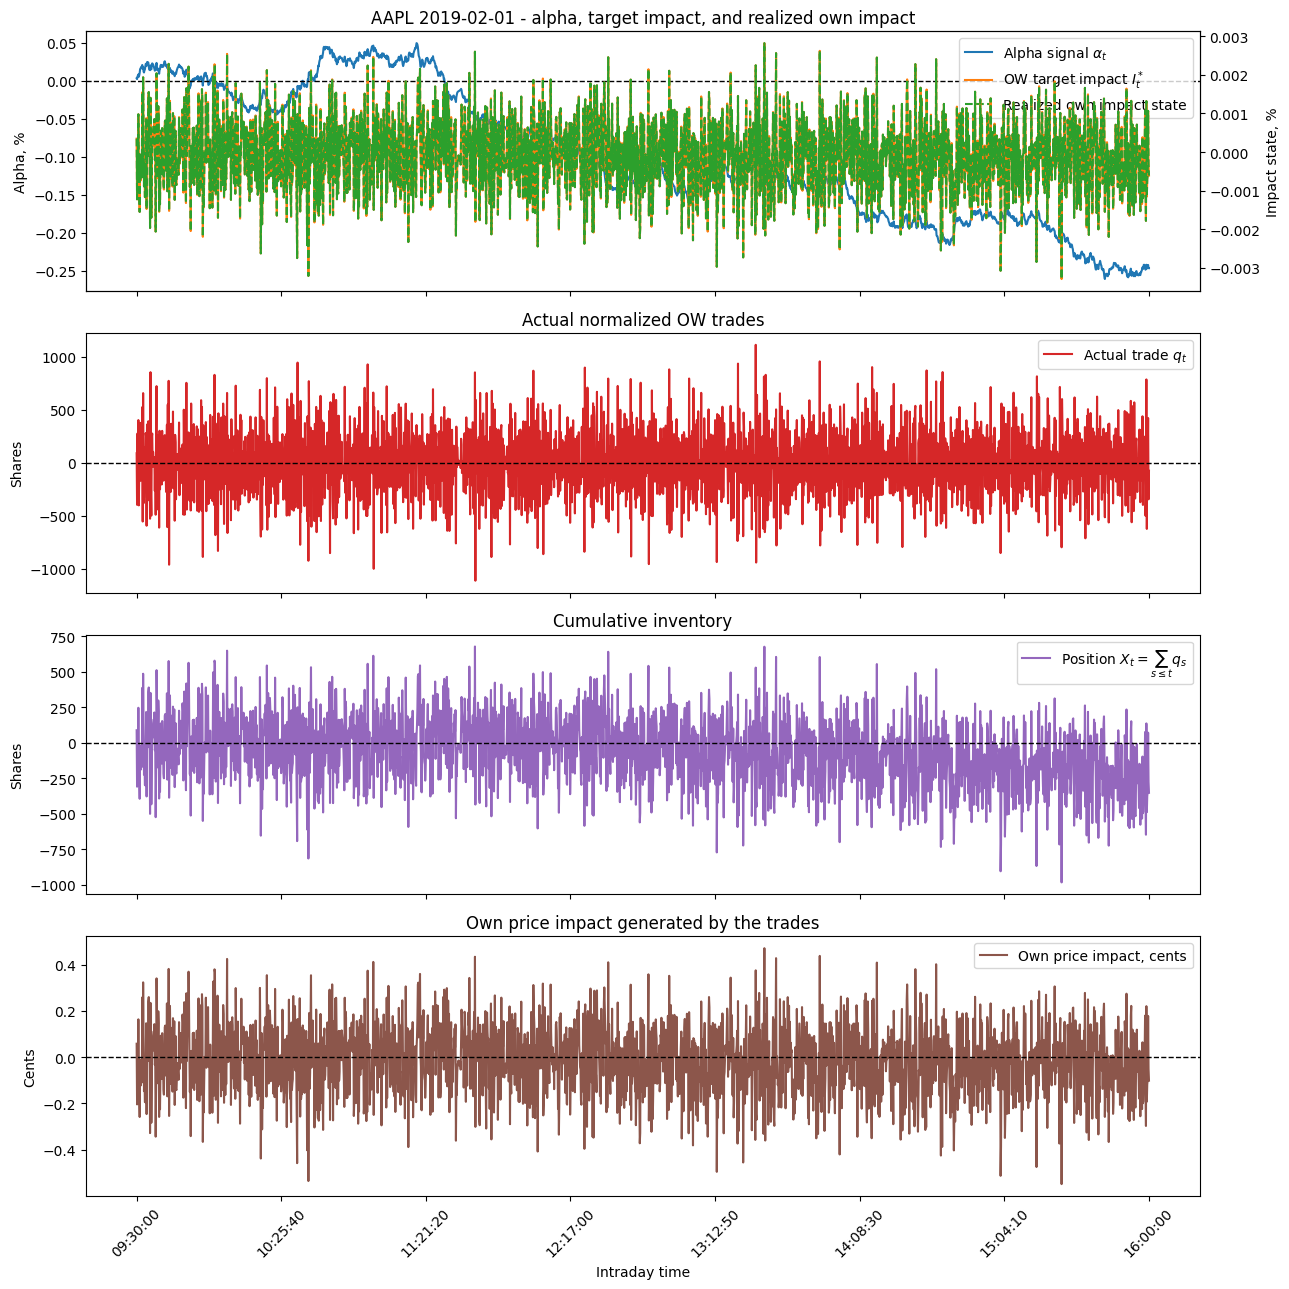

,daily_pnl,impact_cost,max_abs_impact,final_position,total_abs_traded,net_traded,avg_price,traded_notional,model_type,stock,date,lambda_hat,ADV,sigma,half_life_seconds
intraday_only,51.922397,785.404043,0.005489,-352.702691,593692.561905,-352.702691,167.348726,99353693.906763,ow,AAPL,2019-02-01,407.392206,2968462.809524,0.000288,1800.0


In [48]:
stock = "AAPL"

if stock in test_px_df.index.get_level_values("stock"):
    date = test_px_df.loc[stock].index[0]
else:
    stock, date = test_px_df.index[0]

scenario_name = "intraday_only"

# -----------------------------
# Extract alpha-to-trade objects
# -----------------------------
alpha_one = alpha_scenarios[scenario_name].loc[(stock, date)]
I_star_one = target_impact_dfs[scenario_name].loc[(stock, date)]
trades_one = strategy_trade_dfs[scenario_name].loc[(stock, date)]
position_one = trades_one.cumsum()

# -----------------------------
# Run one-stock-day backtest path
# -----------------------------
paths, summary_df = run_one_stock_day_paths_for_strategies(
    stock=stock,
    date=date,
    strategy_trade_dfs={scenario_name: strategy_trade_dfs[scenario_name]},
    model_type="ow",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=dt_seconds,
)

path = paths[scenario_name]

# -----------------------------
# Plot setup
# -----------------------------
x = np.arange(len(alpha_one))
tick_positions = np.linspace(0, len(alpha_one) - 1, 8, dtype=int)
tick_labels = alpha_one.index[tick_positions]

fig, axes = plt.subplots(4, 1, figsize=(13, 13), sharex=True)

# -----------------------------
# 1. Alpha and impact state with separate y-axes
# -----------------------------
ax1 = axes[0]

line1 = ax1.plot(
    x,
    100 * alpha_one.values,
    color="tab:blue",
    label=r"Alpha signal $\alpha_t$",
)

ax1.axhline(0, color="black", linestyle="--", linewidth=1)
ax1.set_ylabel("Alpha, %")
ax1.set_title(f"{stock} {date} - alpha, target impact, and realized own impact")

ax2 = ax1.twinx()

line2 = ax2.plot(
    x,
    100 * I_star_one.values,
    color="tab:orange",
    label=r"OW target impact $I_t^*$",
)

line3 = ax2.plot(
    x,
    100 * path["impact_state"].values,
    color="tab:green",
    linestyle="--",
    label="Realized own impact state",
)

ax2.set_ylabel("Impact state, %")

lines = line1 + line2 + line3
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")

# -----------------------------
# 2. Actual trades q_t
# -----------------------------
axes[1].plot(
    x,
    trades_one.values,
    color="tab:red",
    label=r"Actual trade $q_t$",
)

axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_ylabel("Shares")
axes[1].set_title("Actual normalized OW trades")
axes[1].legend()

# -----------------------------
# 3. Cumulative position
# -----------------------------
axes[2].plot(
    x,
    position_one.values,
    color="tab:purple",
    label=r"Position $X_t = \sum_{s \leq t} q_s$",
)

axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_ylabel("Shares")
axes[2].set_title("Cumulative inventory")
axes[2].legend()

# -----------------------------
# 4. Own impact in price units
# -----------------------------
axes[3].plot(
    x,
    100 * path["impact_in_price"].values,
    color="tab:brown",
    label="Own price impact, cents",
)

axes[3].axhline(0, color="black", linestyle="--", linewidth=1)
axes[3].set_ylabel("Cents")
axes[3].set_title("Own price impact generated by the trades")
axes[3].legend()

# -----------------------------
# Shared x-axis
# -----------------------------
axes[3].set_xticks(tick_positions)
axes[3].set_xticklabels(tick_labels, rotation=45)
axes[3].set_xlabel("Intraday time")

plt.tight_layout()
plt.show()

display(summary_df)

## AFS

In [52]:
afs_fit_df = fit_dfs["afs"]

afs_trades_df, afs_target_impact_df, afs_alpha_mu_df, afs_strategy_scale_df = make_afs_optimal_trade_df(
    alpha_df=synthetic_alpha_df,
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    fit_df=afs_fit_df,
    dt_seconds=10,
    c=0.5,
    normalize_abs_volume=True,
    target_participation=0.20,
)

NameError: name 'make_afs_optimal_trade_df' is not defined

# Reduced form

In [53]:
(
    reduced_trades_df,
    reduced_target_impact_df,
    reduced_alpha_mu_df,
    reduced_local_volume_df,
    reduced_gamma_prime_df,
    reduced_strategy_scale_df,
) = make_reduced_form_optimal_trade_df(
    alpha_df=synthetic_alpha_df,
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_df=fit_dfs["reduced_form"],
    dt_seconds=10,
    normalize_abs_volume=True,
    target_participation=0.20,
    use_dynamic_target=True,
)

In [54]:
strategy_trade_dfs = {
    "reduced_form_optimal": reduced_trades_df,
}

reduced_backtest_results = run_strategy_backtests_for_model(
    strategy_trade_dfs=strategy_trade_dfs,
    model_type="reduced_form",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=10,
)

In [55]:
stock = "AAPL"
date = "2019-02-21"

paths, summaries = run_one_stock_day_paths_for_strategies(
    stock=stock,
    date=date,
    strategy_trade_dfs={
        "OW optimal": trades_df,
        "Reduced-form optimal": reduced_trades_df,
    },
    model_type="reduced_form",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=10,
)

summaries

,daily_pnl,impact_cost,max_abs_impact,final_position,total_abs_traded,net_traded,avg_price,traded_notional,model_type,stock,date,lambda_hat,ADV,sigma,half_life_seconds
OW optimal,-308795.889503,252713.793416,0.526141,0.0,593692.561905,0.0,171.293967,101695953.906847,reduced_form,AAPL,2019-02-21,106.653594,2968462.809524,0.000288,600.0
Reduced-form optimal,-2512.324541,2623.822551,0.026233,20.261165,593692.561905,20.261165,171.293967,101695953.906847,reduced_form,AAPL,2019-02-21,106.653594,2968462.809524,0.000288,600.0


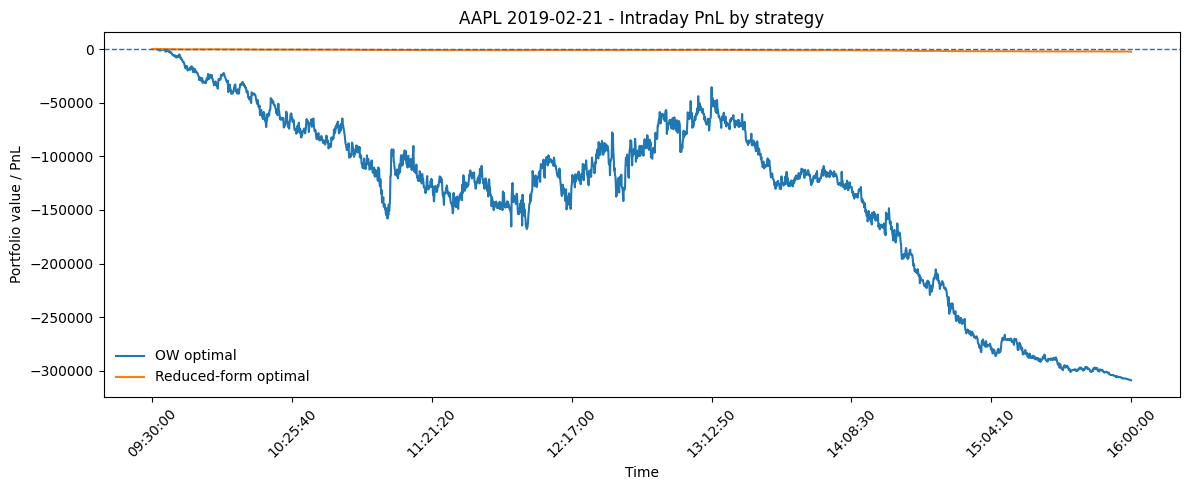

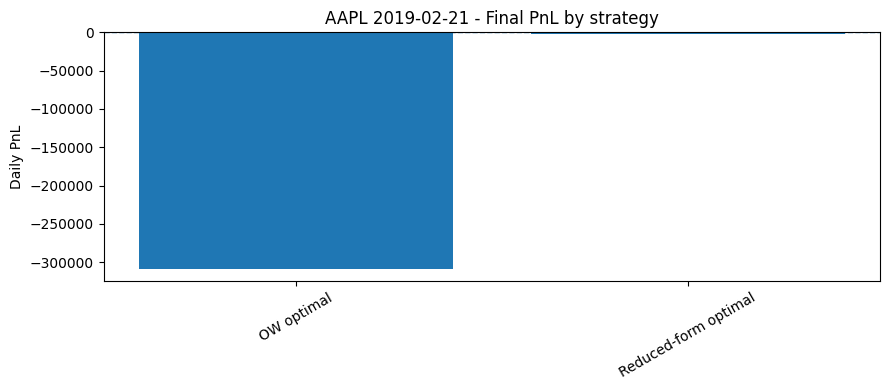

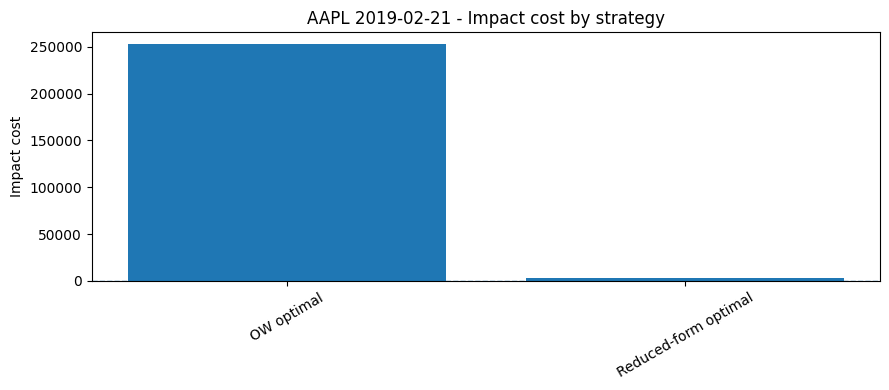

In [56]:
plot_one_stock_day_pnl_comparison(paths, stock, date)
plot_one_stock_day_final_pnl_bar(summaries, stock, date)
plot_one_stock_day_impact_cost_bar(summaries, stock, date)